# 2. LoRA i trening

Koriscen je Qwen2.5-Coder-1.5B sa dve implementacije adaptera: sopstvenom PyTorch implementacijom i bibliotekom PEFT. Numericki primer ispod radi na CPU-u. Metrike punog treninga citaju se iz sacuvanih rezultata.

## Linearni sloj

Za ulazni vektor $x$, zamrznutu tezinu $W$ i bias $b$ sloj racuna:

$$y = Wx + b + \frac{\alpha}{r}BA\,\mathrm{Dropout}(x).$$

Matrice $A \in \mathbb{R}^{r \times d_{\mathrm{in}}}$ i $B \in \mathbb{R}^{d_{\mathrm{out}} \times r}$ su trenabilne. $A$ se inicijalizuje Kaiming postupkom, a $B$ nulama. Zato je pocetni izlaz jednak baznom sloju. U sledecem primeru dropout je iskljucen.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from code_lora.lora import LoRAConfig, LoRALinear, inject_lora

_ = torch.manual_seed(42)

In [2]:
layer = LoRALinear(nn.Linear(8, 6), rank=2, alpha=4, dropout=0)
x = torch.randn(128, 8)
base_output = layer.base_layer(x).detach()
print("A:", tuple(layer.lora_A.shape), "B:", tuple(layer.lora_B.shape))
print("Pocetna razlika:", (layer(x) - base_output).abs().max().item())

A: (2, 8) B: (6, 2)
Pocetna razlika: 0.0


### Implementacija forward prolaza

Ispod je metoda direktno iz `src/code_lora/lora.py`. Dva poziva `F.linear` racunaju transformacije matricama A i B. Njihov izlaz se skalira sa `alpha / rank` i sabira sa izlazom baznog sloja. Ako su tezine prethodno spojene metodom `merge()`, dodatak je vec sadrzan u baznoj matrici.

In [3]:
import inspect
from IPython.display import Code, display

display(Code(inspect.getsource(LoRALinear.forward), language="python"))

def forward(self, inputs: Tensor) -> Tensor:
        base_output = self.base_layer(inputs)
        if self.merged:
            return base_output

        adapter_inputs = self.lora_dropout(inputs).to(dtype=self.lora_A.dtype)
        adapter_output = F.linear(F.linear(adapter_inputs, self.lora_A), self.lora_B)
        return base_output + adapter_output.to(dtype=base_output.dtype) * self.scaling

## Izbor slojeva

Adapteri su dodati samo u `q_proj` i `v_proj` projekcije. U Qwen modelu to je ukupno 56 slojeva. Funkcija `inject_lora` bira module po imenu i zamrzava ostale parametre. Ovde je prikazano njeno dejstvo na tri male linearne projekcije.

In [4]:
projections = nn.ModuleDict({name: nn.Linear(8, 8) for name in ("q_proj", "k_proj", "v_proj")})
replaced = inject_lora(projections, LoRAConfig(rank=2, alpha=4, dropout=0))
print("Zamenjeni moduli:", replaced)
pd.DataFrame([
    (name, tuple(parameter.shape), parameter.requires_grad)
    for name, parameter in projections.named_parameters()
], columns=["Parametar", "Oblik", "Trenabilan"])

Zamenjeni moduli: ['q_proj', 'v_proj']


,Parametar,Oblik,Trenabilan
0,q_proj.lora_A,"(2, 8)",True
1,q_proj.lora_B,"(8, 2)",True
2,q_proj.base_layer.weight,"(8, 8)",False
3,q_proj.base_layer.bias,"(8,)",False
4,k_proj.weight,"(8, 8)",False
5,k_proj.bias,"(8,)",False
6,v_proj.lora_A,"(2, 8)",True
7,v_proj.lora_B,"(8, 2)",True
8,v_proj.base_layer.weight,"(8, 8)",False
9,v_proj.base_layer.bias,"(8,)",False


### Isti izbor slojeva kroz PEFT

Funkcija `prepare_lora_model` priprema obe implementacije za zajednicku trening petlju. Za `custom` poziva nas `inject_lora`, a za `peft` koristi `get_peft_model` sa istim rank-om, alpha vrednoscu i ciljnim modulima.

Ovde koristimo mali Qwen sa nasumicnim tezinama i rank-om 2 da prikazemo broj parametara obe implementacije. Njegove dimenzije i tezine nisu one iz glavnog eksperimenta.

In [5]:
from copy import deepcopy
from transformers import Qwen2Config, Qwen2ForCausalLM
from code_lora.lora import count_parameters
from code_lora.training import prepare_lora_model

tiny_config = Qwen2Config(
    vocab_size=32, hidden_size=16, intermediate_size=32,
    num_hidden_layers=1, num_attention_heads=2, num_key_value_heads=2,
)
tiny_base = Qwen2ForCausalLM(tiny_config)
adapter_config = LoRAConfig(rank=2, alpha=4, dropout=0)
parameter_counts = {}
for backend in ("custom", "peft"):
    adapted = prepare_lora_model(deepcopy(tiny_base), backend, adapter_config)
    parameter_counts[backend] = count_parameters(adapted)
pd.DataFrame(parameter_counts).T

,total,trainable,trainable_percent
custom,3808.0,128.0,3.361345
peft,3808.0,128.0,3.361345


## Ucenje adaptera na malom primeru

Linearnom sloju zadajemo cilj koji se od baznog izlaza razlikuje za transformaciju ranga 2. Adam optimizuje A i B tokom 60 koraka. Ovde koristimo MSE; u treningu jezickog modela koriscena je unakrsna entropija za sledeci token.

MSE pre prvog i pre poslednjeg koraka: 0.4664 -> 0.0002
Bazna tezina ostala ista: True


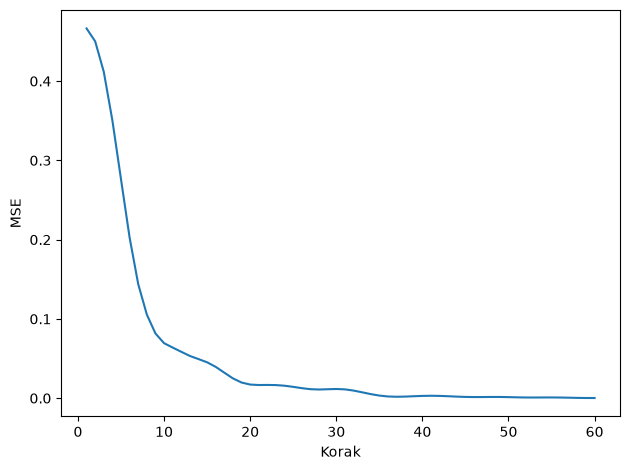

In [6]:
target = base_output + 0.2 * (x @ torch.randn(8, 2) @ torch.randn(2, 6))
weight_before = layer.base_layer.weight.detach().clone()
optimizer = torch.optim.Adam([p for p in layer.parameters() if p.requires_grad], lr=0.05)
losses = []
for _ in range(60):
    optimizer.zero_grad()
    loss = nn.functional.mse_loss(layer(x), target)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"MSE pre prvog i pre poslednjeg koraka: {losses[0]:.4f} -> {losses[-1]:.4f}")
print("Bazna tezina ostala ista:", torch.equal(weight_before, layer.base_layer.weight))
plt.plot(range(1, 61), losses)
plt.xlabel("Korak")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## Trening na 20.000 primera

Oba adaptera su trenirana jednu epohu: rank 16, alpha 32, dropout 0,05, AdamW sa stopom ucenja 0,0002, cosine rasporedom i 3% warmup koraka. Korisceni su BF16 autocast, FP32 parametri i gradient checkpointing.

Svaka grupa od 32 primera podeljena je u cetiri micro-batcha od po osam primera. Loss svakog micro-batcha deli se sa cetiri, poziva se `backward()`, a optimizer azurira tezine tek posle cetvrtog micro-batcha. Ukupno je napravljeno 625 azuriranja.

Loss obuhvata samo tokene odgovora: prompt i padding imaju labelu `-100`. Redosled primera je isti za custom i PEFT. Petlja je u [training.py](../src/code_lora/training.py), a parametri u [experiment.yaml](../configs/experiment.yaml).

Za punu grupu od 32 primera, jedno azuriranje u trening petlji svodi se na sledeci isecek. `microbatches` ovde oznacava cetiri batcha od po osam primera.

```python
optimizer.zero_grad(set_to_none=True)
for batch in microbatches:
    batch = {name: tensor.to(device) for name, tensor in batch.items()}
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        loss = model(**batch, use_cache=False).loss / 4
    loss.backward()

torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
optimizer.step()
scheduler.step()
```

Sva cetiri poziva `backward()` sabiraju gradijente pre jednog `optimizer.step()`. AdamW dobija samo parametre sa `requires_grad=True`. Funkcija `train` ponderise loss prema broju primera u micro-batchu i celoj grupi, ukljucujuci poslednju grupu ako ima manje od 32 primera.

In [7]:
training = json.loads((ROOT / "results/training_summary.json").read_text(encoding="utf-8"))
runs = pd.DataFrame(training["runs"]).T
runs["vreme_min"] = runs["wall_time_seconds"] / 60
print(f"Trenabilni parametri: {training['trainable_parameters']:,} ({training['trainable_percent']:.3f}%)")
runs[["vreme_min", "tokens_per_second", "peak_memory_gib", "adapter_size_mib"]].round(2)

Trenabilni parametri: 2,179,072 (0.141%)


,vreme_min,tokens_per_second,peak_memory_gib,adapter_size_mib
custom,83.18,1825.01,23.88,8.35
peft,93.80,1618.31,23.88,8.33


### Loss tokom treninga

Kriva prikazuje loss iz logova treninga: prvi korak i svaki 25. korak, zakljucno sa 625. Loss pripada konkretnoj grupi primera, pa njegov tok zavisi i od redosleda podataka.

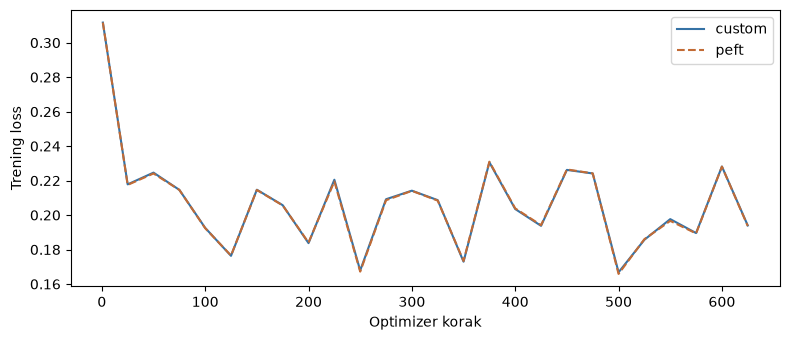

In [8]:
curve = pd.DataFrame(training["loss_curve"]).set_index("step")
ax = curve.plot(figsize=(8, 3.5), style=["-", "--"], color=["#3572a5", "#c26b35"])
ax.set(xlabel="Optimizer korak", ylabel="Trening loss")
plt.tight_layout()
plt.show()

### Sta se cuva u adapteru?

Custom adapter sadrzi matrice A i B, uz JSON konfiguraciju i identitet baznog modela. Bazne tezine se pri ucitavanju uzimaju iz baznog Qwen modela. Zato sacuvani adapter zauzima oko 8,35 MiB.

Za male projekcije iz prethodne celije, `lora_state_dict` izdvaja sledece tenzore. Funkcija `save_lora_adapter` isti ovaj recnik upisuje u `adapter_model.pt`.

In [9]:
from code_lora.serialization import lora_state_dict

state = lora_state_dict(projections)
pd.DataFrame([
    (name, tuple(tensor.shape), tensor.numel())
    for name, tensor in state.items()
], columns=["Sacuvani parametar", "Oblik", "Broj elemenata"])

,Sacuvani parametar,Oblik,Broj elemenata
0,q_proj.lora_A,"(2, 8)",16
1,q_proj.lora_B,"(8, 2)",16
2,v_proj.lora_A,"(2, 8)",16
3,v_proj.lora_B,"(8, 2)",16


## Validacija

Loss je racunat na istih 2.000 primera i ponderisan brojem nemaskiranih tokena odgovora. Perplexity je $e^{\mathrm{loss}}$. Ove metrike koriste poznati odgovor pri predvidjanju sledeceg tokena; ispravnost samostalno generisanog programa proverava se benchmark testovima.

In [10]:
validation = pd.DataFrame(training["validation_2k"]).T
validation.index.name = "Varijanta"
validation.round(6)

,loss,perplexity
Varijanta,,
base,0.340008,1.404959
custom,0.191903,1.211553
peft,0.192050,1.211731


Custom trening trajao je 83,18 minuta, a PEFT 93,80 minuta. To je 11,3% krace vreme u ovom paru izvrsavanja; brzina nije merena kroz vise ponovljenih treninga.

Validacioni loss opao je sa 0,3400 na oko 0,192 za oba adaptera. Razlika izmedju custom i PEFT iznosi 0,000147.